In [1]:
## Name and description

In [1]:
#load packages
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from tifffile import imread
from scipy import optimize
from scipy import stats

In [2]:
# loading images
path = "C:/Users/zuzka/Desktop/rasy/experiment2/"
folder_raw = 'tiff_files/'

folder_output = "results/"

files_raw = [g for g in os.listdir(path + folder_raw) if g.endswith(".tif")]

imgs_raw = [imread(path + folder_raw + filename) for filename in files_raw]


print('Loaded images:')
for i in range(len(files_raw)):
    print(files_raw[i], '-dims:', imgs_raw[i].shape)


Loaded images:
2023-03-16_Synechocystis-YFP.lif - TileScan 5Position 15.tif -dims: (15, 4, 928, 928)
2023-03-16_Synechocystis-YFP.lif - TileScan 5Position 16.tif -dims: (15, 4, 928, 928)
2023-03-16_Synechocystis-YFP.lif - TileScan 5Position 17.tif -dims: (15, 4, 928, 928)
2023-03-16_Synechocystis-YFP.lif - TileScan 5Position 18.tif -dims: (15, 4, 928, 928)
2023-03-16_Synechocystis-YFP.lif - TileScan 5Position 19.tif -dims: (15, 4, 928, 928)
2023-03-16_Synechocystis-YFP.lif - TileScan 5Position 20.tif -dims: (15, 4, 928, 928)
2023-03-16_Synechocystis-YFP.lif - TileScan 5Position 21.tif -dims: (15, 4, 928, 928)
2023-03-16_Synechocystis-YFP.lif - TileScan 5Position 22.tif -dims: (15, 4, 928, 928)
2023-03-16_Synechocystis-YFP.lif - TileScan 5Position 23.tif -dims: (15, 4, 928, 928)
2023-03-16_Synechocystis-YFP.lif - TileScan 5Position 24.tif -dims: (15, 4, 928, 928)
2023-03-16_Synechocystis-YFP.lif - TileScan 5Position 25.tif -dims: (15, 4, 928, 928)
2023-03-16_Synechocystis-YFP.lif - Tile

In [21]:
# create list of image names
# names = [(iname.split(' ')[0]).replace('d3', 'd1') for iname in files_ch1]

In [22]:
#for idx in range(len(files_raw)):
#    imgs_raw[idx] = imgs_raw[idx].transpose((2,3,1,0))

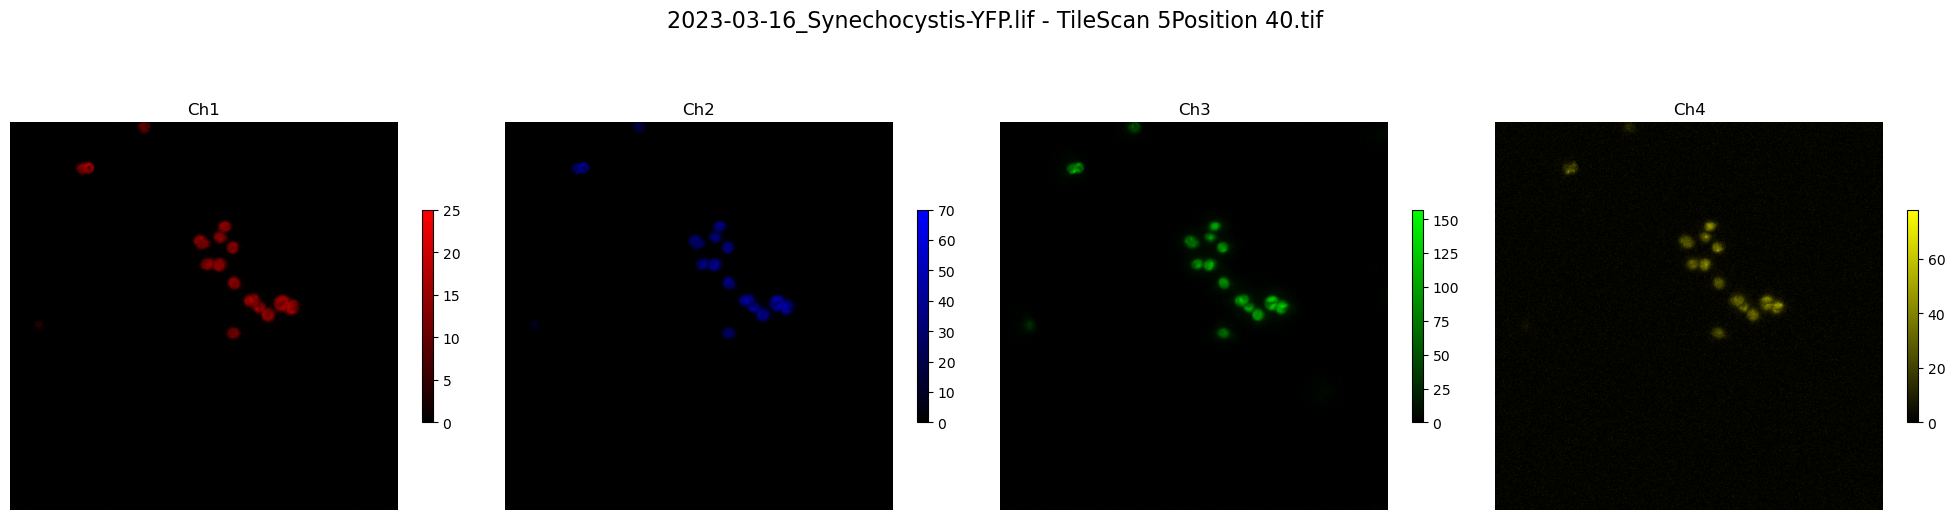

In [154]:
# view 1 image and its max projection of channels
from matplotlib.colors import LinearSegmentedColormap
colors = [(0, 0, 0), (1, 0, 0)] # first color is black, last is red
rcm = LinearSegmentedColormap.from_list("Custom", [(0, 0, 0), (1, 0, 0)], N=256)
gcm = LinearSegmentedColormap.from_list("Custom", [(0, 0, 0), (0, 1, 0)], N=256)
bcm = LinearSegmentedColormap.from_list("Custom", [(0, 0, 0), (0, 0, 1)], N=256)
ycm = LinearSegmentedColormap.from_list("Custom", [(0, 0, 0), (1, 1, 0)], N=256)

val = 23

s,ch,w,h = imgs_raw[val].shape
im_proj = np.max(imgs_raw[val], axis=0)


luts = [rcm, bcm, gcm, ycm]
plt.figure(figsize=(20,6))
for channel in range(ch):
    plt.subplot(int("1"+str(ch)+str(channel+1)))
    mask = im_proj[channel] < 5
    im_proj[channel][mask]=0
    plt.imshow(im_proj[channel], luts[channel])
    plt.colorbar(shrink=0.4)
    plt.axis('off')
    plt.title('Ch'+str(channel+1)) 

plt.suptitle(files_raw[val], fontsize=16)

plt.tight_layout()

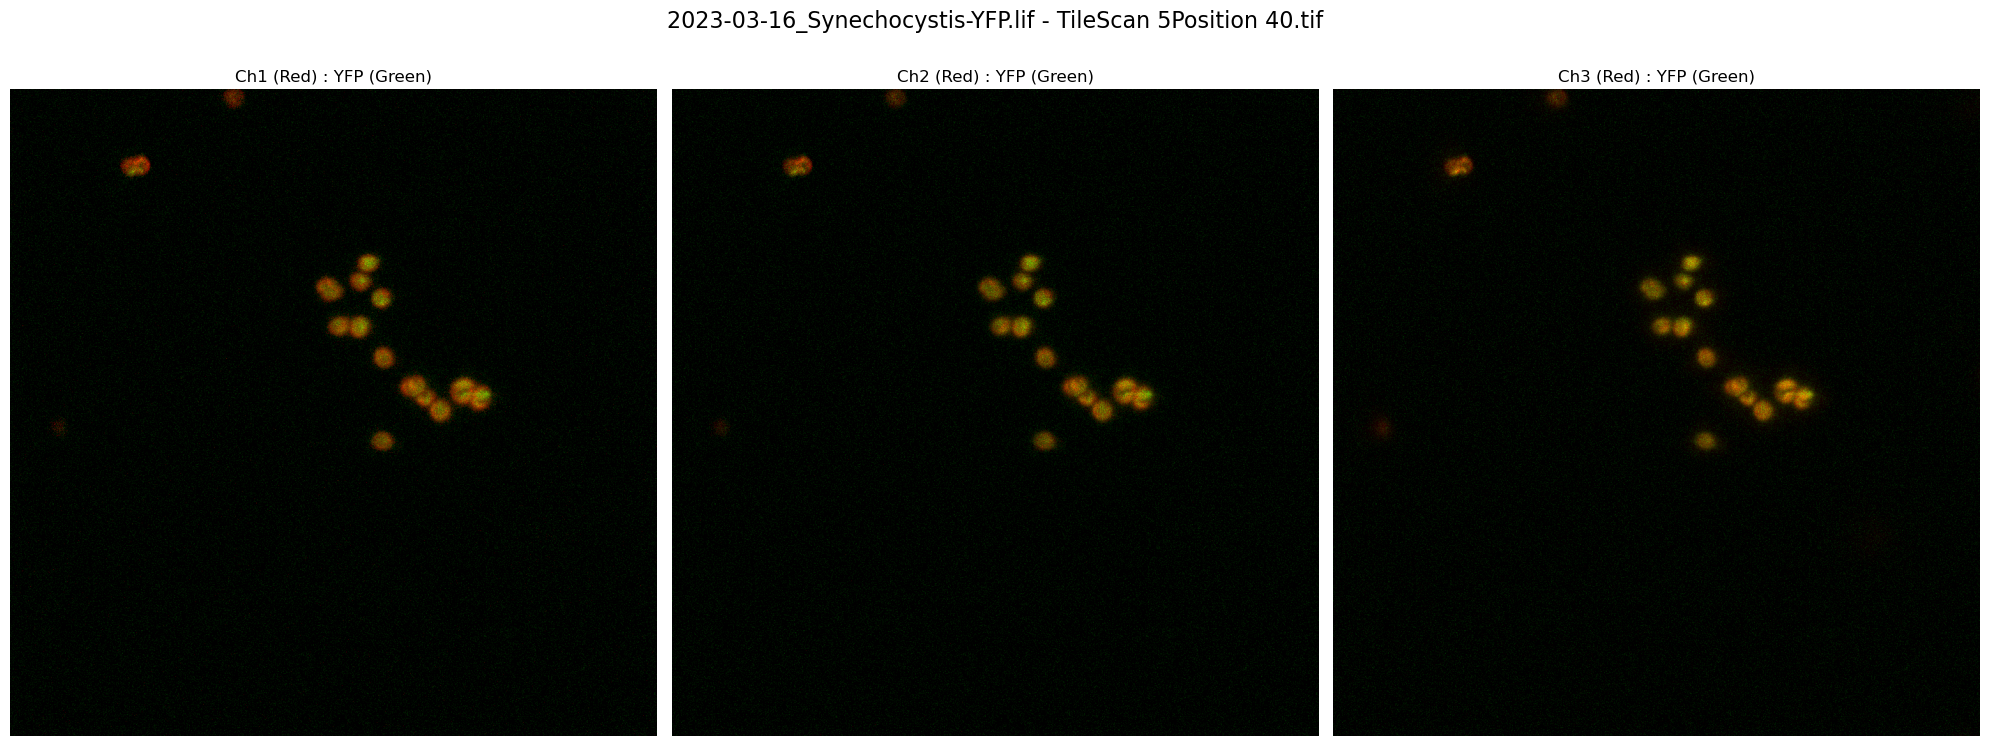

In [155]:
empty_blue = np.zeros(im_proj[0].shape)

plt.figure(figsize=(20,8))
for channel in range(3):
    plt.subplot(int("13"+str(channel+1)))
    test = np.array([im_proj[channel]/im_proj[channel].max(), im_proj[3]/im_proj[3].max(), empty_blue])
    test = test.transpose((1,2,0))
    plt.imshow(test)
    plt.title('Ch'+str(channel+1)+' (Red) : YFP (Green)')
    plt.axis('off')

plt.suptitle(files_raw[val], fontsize=16)

plt.tight_layout()

In [180]:
df_list, df_corr_list = [], []
for num in range(len(imgs_raw)):
    trasp = imgs_raw[num].transpose(1,0,2,3)
    ps1 = np.where(trasp[0]<10, np.nan, trasp[0])
    ps2 = np.where(trasp[1]<30, np.nan, trasp[1])
    ps2a = np.where(trasp[2]<50, np.nan, trasp[2])
    yfp = np.where(trasp[3]<20, np.nan, trasp[3])
    df = pd.DataFrame(np.array([ps1.flatten(), ps2.flatten(),ps2a.flatten(), yfp.flatten()]).T,
                  columns=['PSII','PSIIa','PSI','YFP'])
    #df = df[df>10]
    df_list.append(df)
    df_corr_list.append(df.corr())

In [181]:
len(df_list[0][::4])

3229440

<Figure size 2000x1500 with 0 Axes>

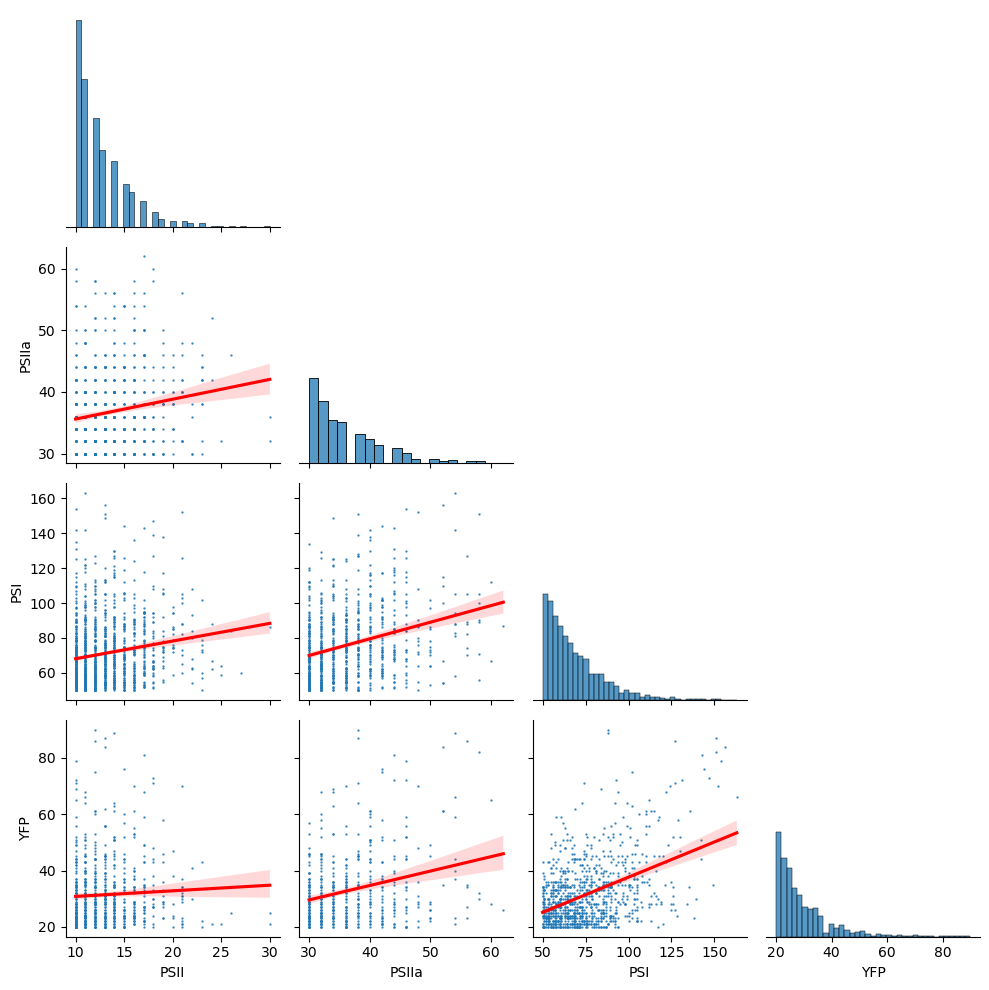

In [182]:
# ploting pairplot for individual images

image_num = 0

plt.figure(figsize=(20, 15))

pairplot = sns.pairplot(df_list[image_num][::5], # reduced input data
                        kind="reg", 
                        corner=True,
                        #s=10,
                        plot_kws=dict(scatter_kws=dict(s=0.5), line_kws=dict(color='red')),
                        )

plt.tight_layout()
plt.show()

In [184]:
# plotting all images
size = len(files_raw)
r,c = 7,4

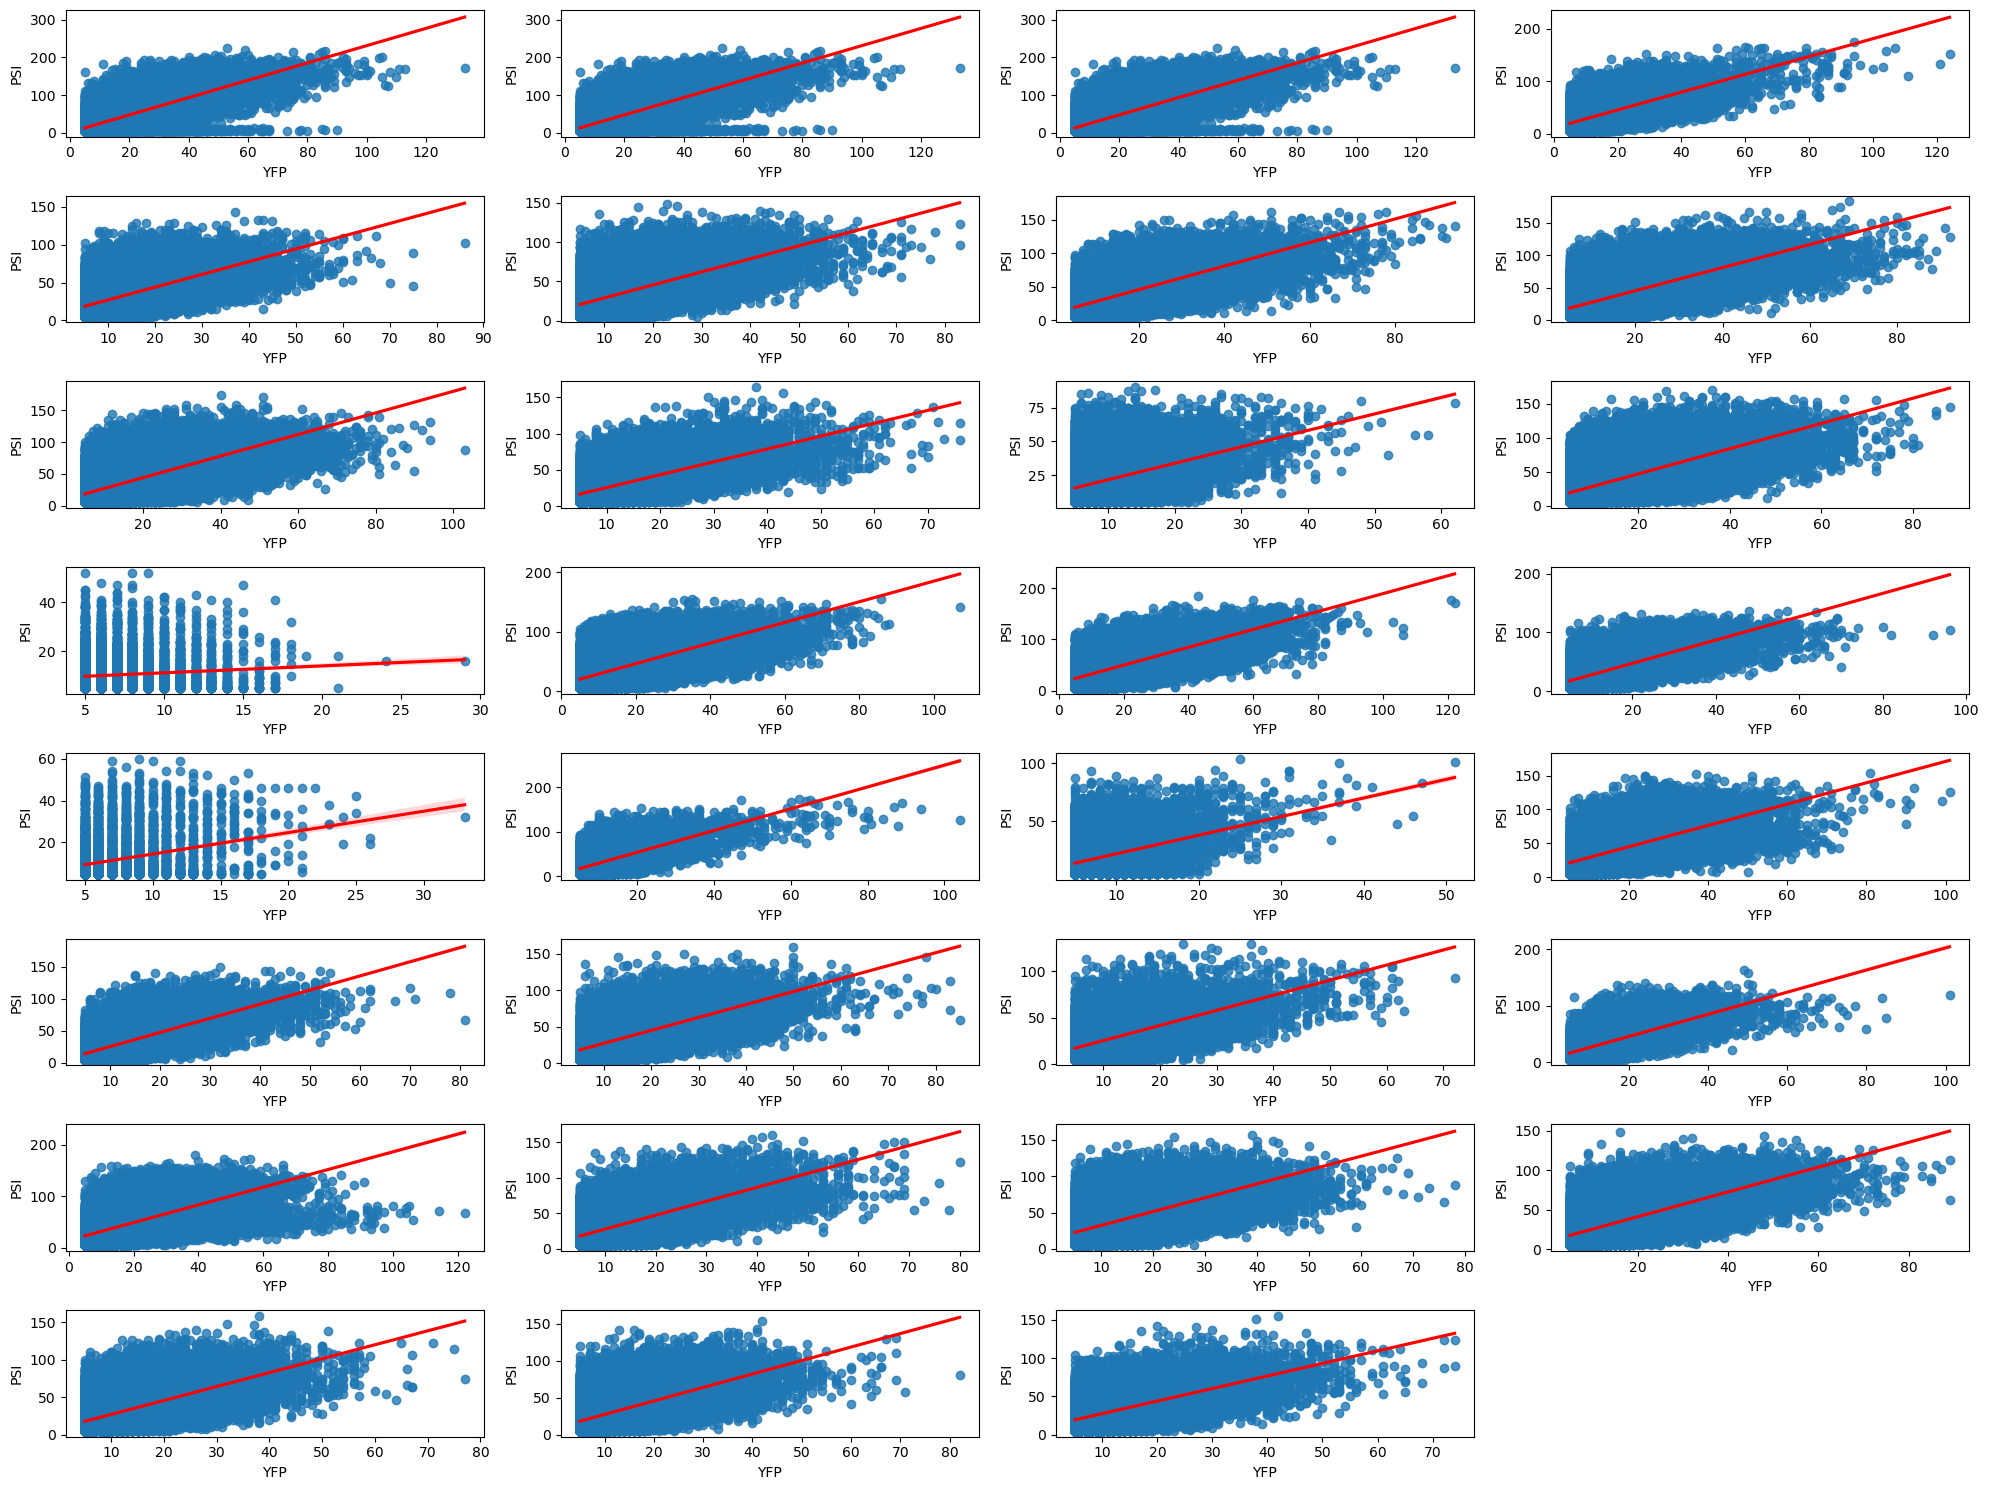

In [19]:
#sns.set(style="ticks", color_codes=True)

plt.figure(figsize=(20, 15))

for i in range(size):
        plt.subplot((r),(c),(i+1))
        regplot = sns.regplot(y=df_list[i]['PSI'], x=df_list[i]['YFP'],
                              line_kws={'color':'red'},
                              scatter_kws={'s':1}
                                )


plt.tight_layout()
plt.show()

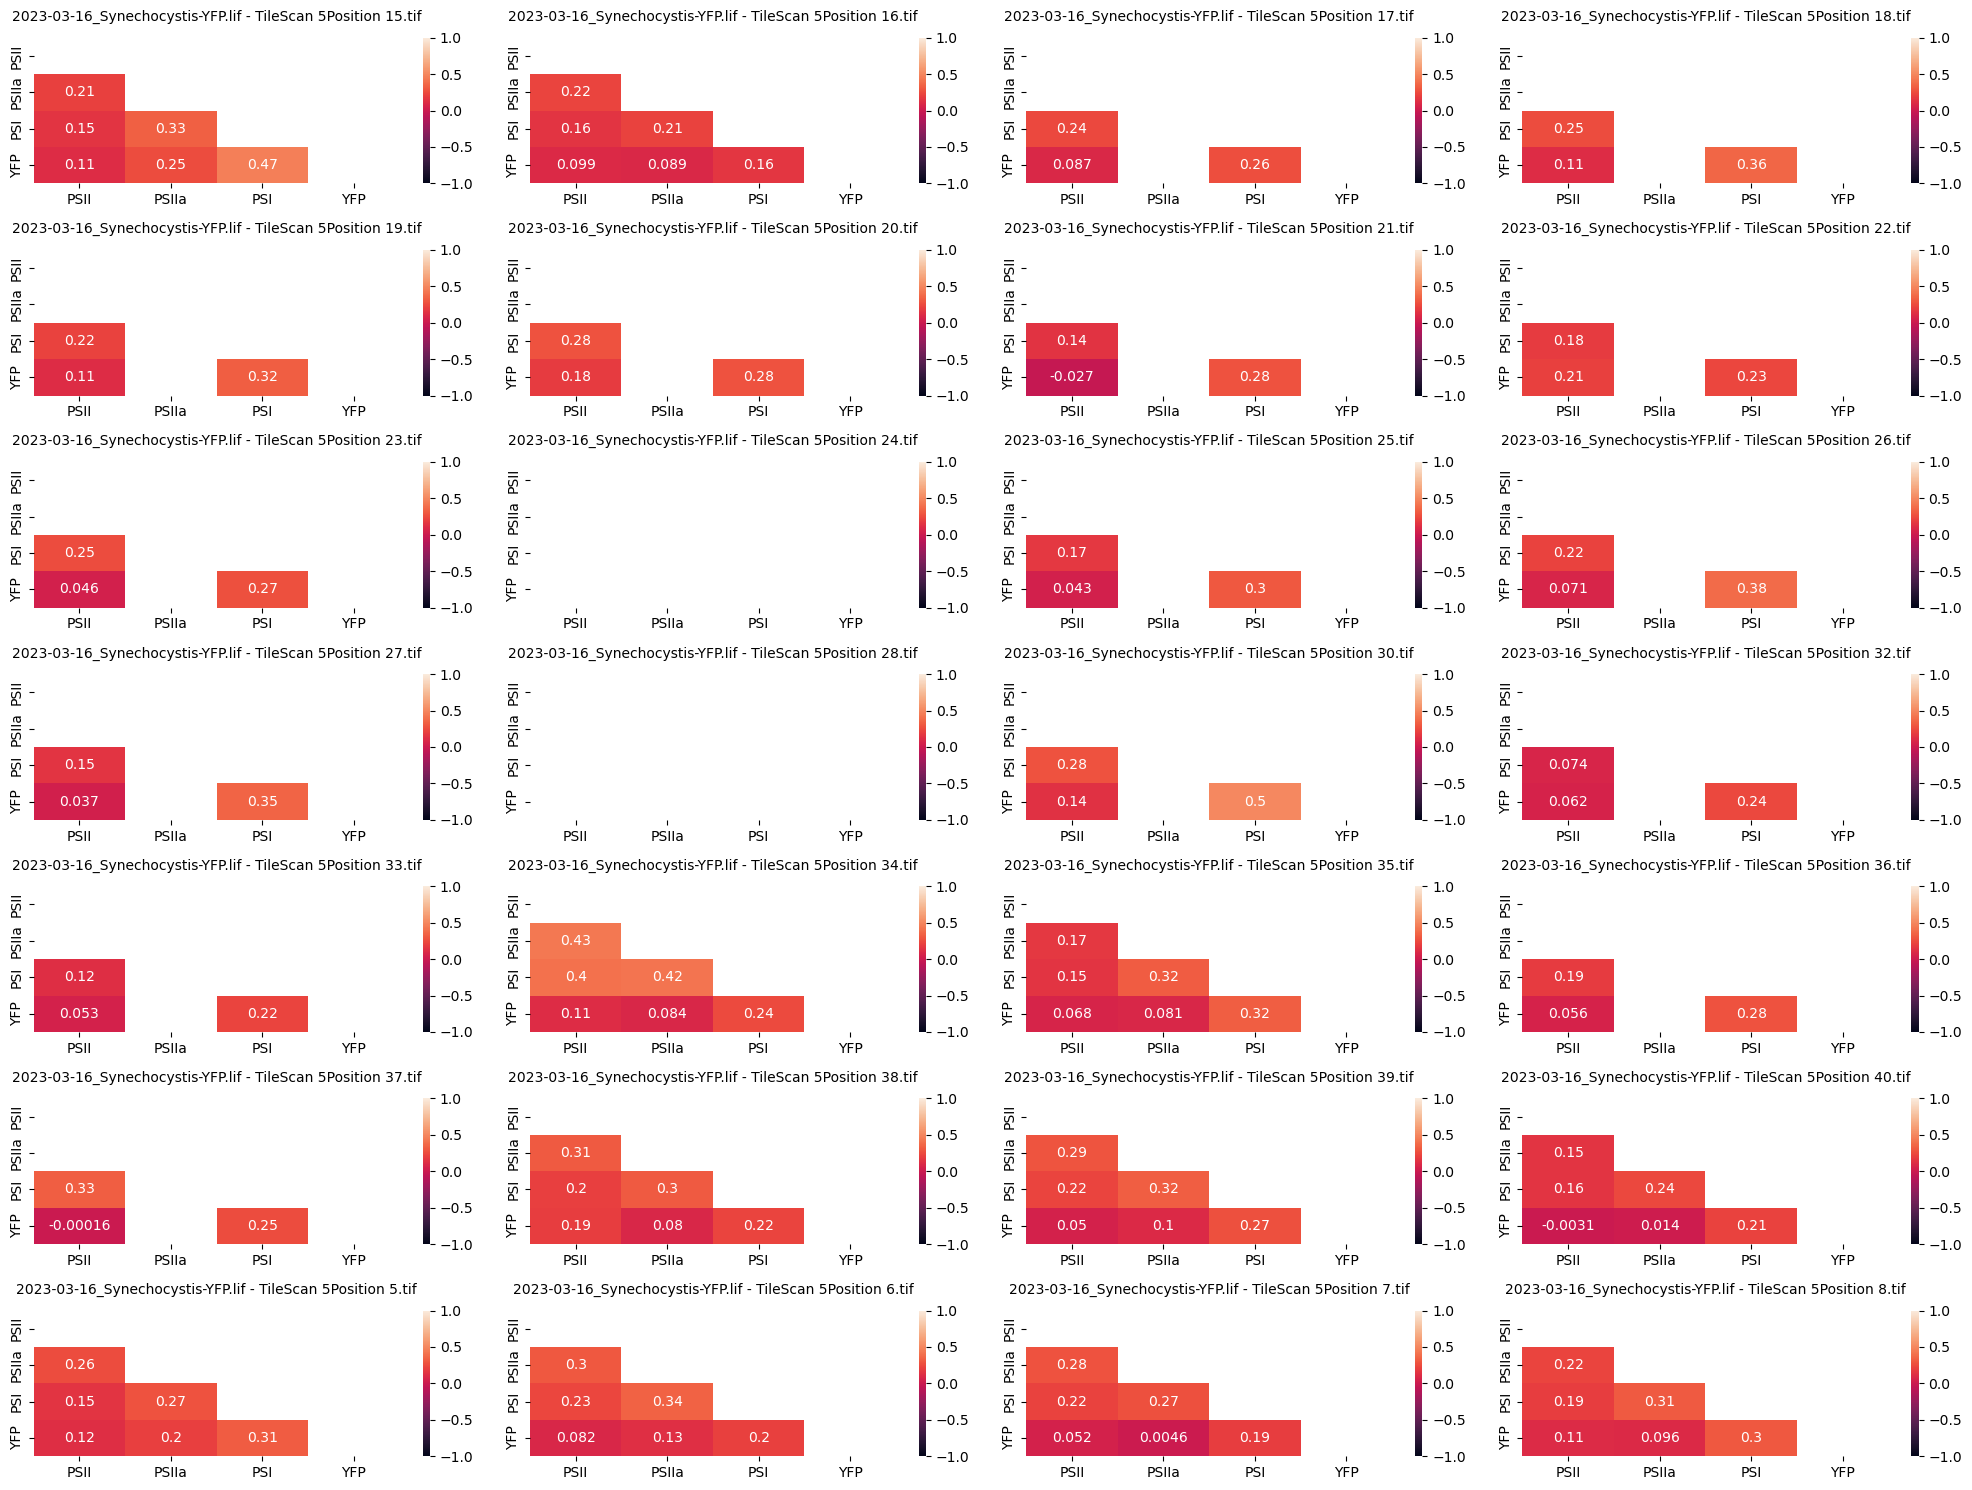

In [185]:
plt.figure(figsize=(20, 15))

for i in range(size):
        plt.subplot((r),(c),(i+1))
        triangle = np.triu(np.ones_like(df_corr_list[i], dtype=bool))
        heatmap = sns.heatmap(df_corr_list[i], mask = triangle, vmin=-1, vmax=1, annot=True)
        heatmap.set_title(files_raw[i], fontdict={'fontsize':10}, pad=12)


plt.tight_layout()
plt.show()

In [187]:
# init
pears_df = pd.DataFrame(df_corr_list[0]['YFP'][0:3])
pears_df['channel'] = pears_df.index
pears_df['dataset'] = files_raw[0]
pears_df = pears_df.rename(columns={"YFP": "YFP_pearson_r"})

#loop
for i in range(1,len(df_corr_list)):
    x = pd.DataFrame(df_corr_list[i]['YFP'][0:3])
    x['channel'] = x.index
    x['dataset'] = files_raw[i]
    x = x.rename(columns={"YFP": "YFP_pearson_r"})
    pears_df = pd.concat([pears_df, x], axis=0)

pears_df.head()

,YFP_pearson_r,channel,dataset
PSII,0.110844,PSII,2023-03-16_Synechocystis-YFP.lif - TileScan 5P...
PSIIa,0.254951,PSIIa,2023-03-16_Synechocystis-YFP.lif - TileScan 5P...
PSI,0.467158,PSI,2023-03-16_Synechocystis-YFP.lif - TileScan 5P...
PSII,0.098602,PSII,2023-03-16_Synechocystis-YFP.lif - TileScan 5P...
PSIIa,0.089420,PSIIa,2023-03-16_Synechocystis-YFP.lif - TileScan 5P...


<AxesSubplot:xlabel='channel', ylabel='YFP_pearson_r'>

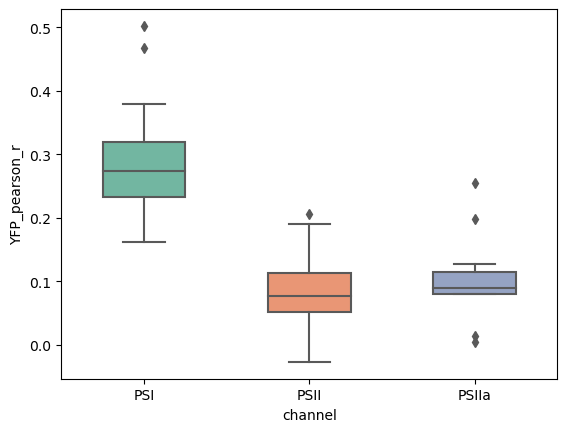

In [188]:
sns.boxplot(data=pears_df, x='channel', y='YFP_pearson_r',
    palette='Set2', 
    width=0.5, 
    order=['PSI','PSII','PSIIa']
    )

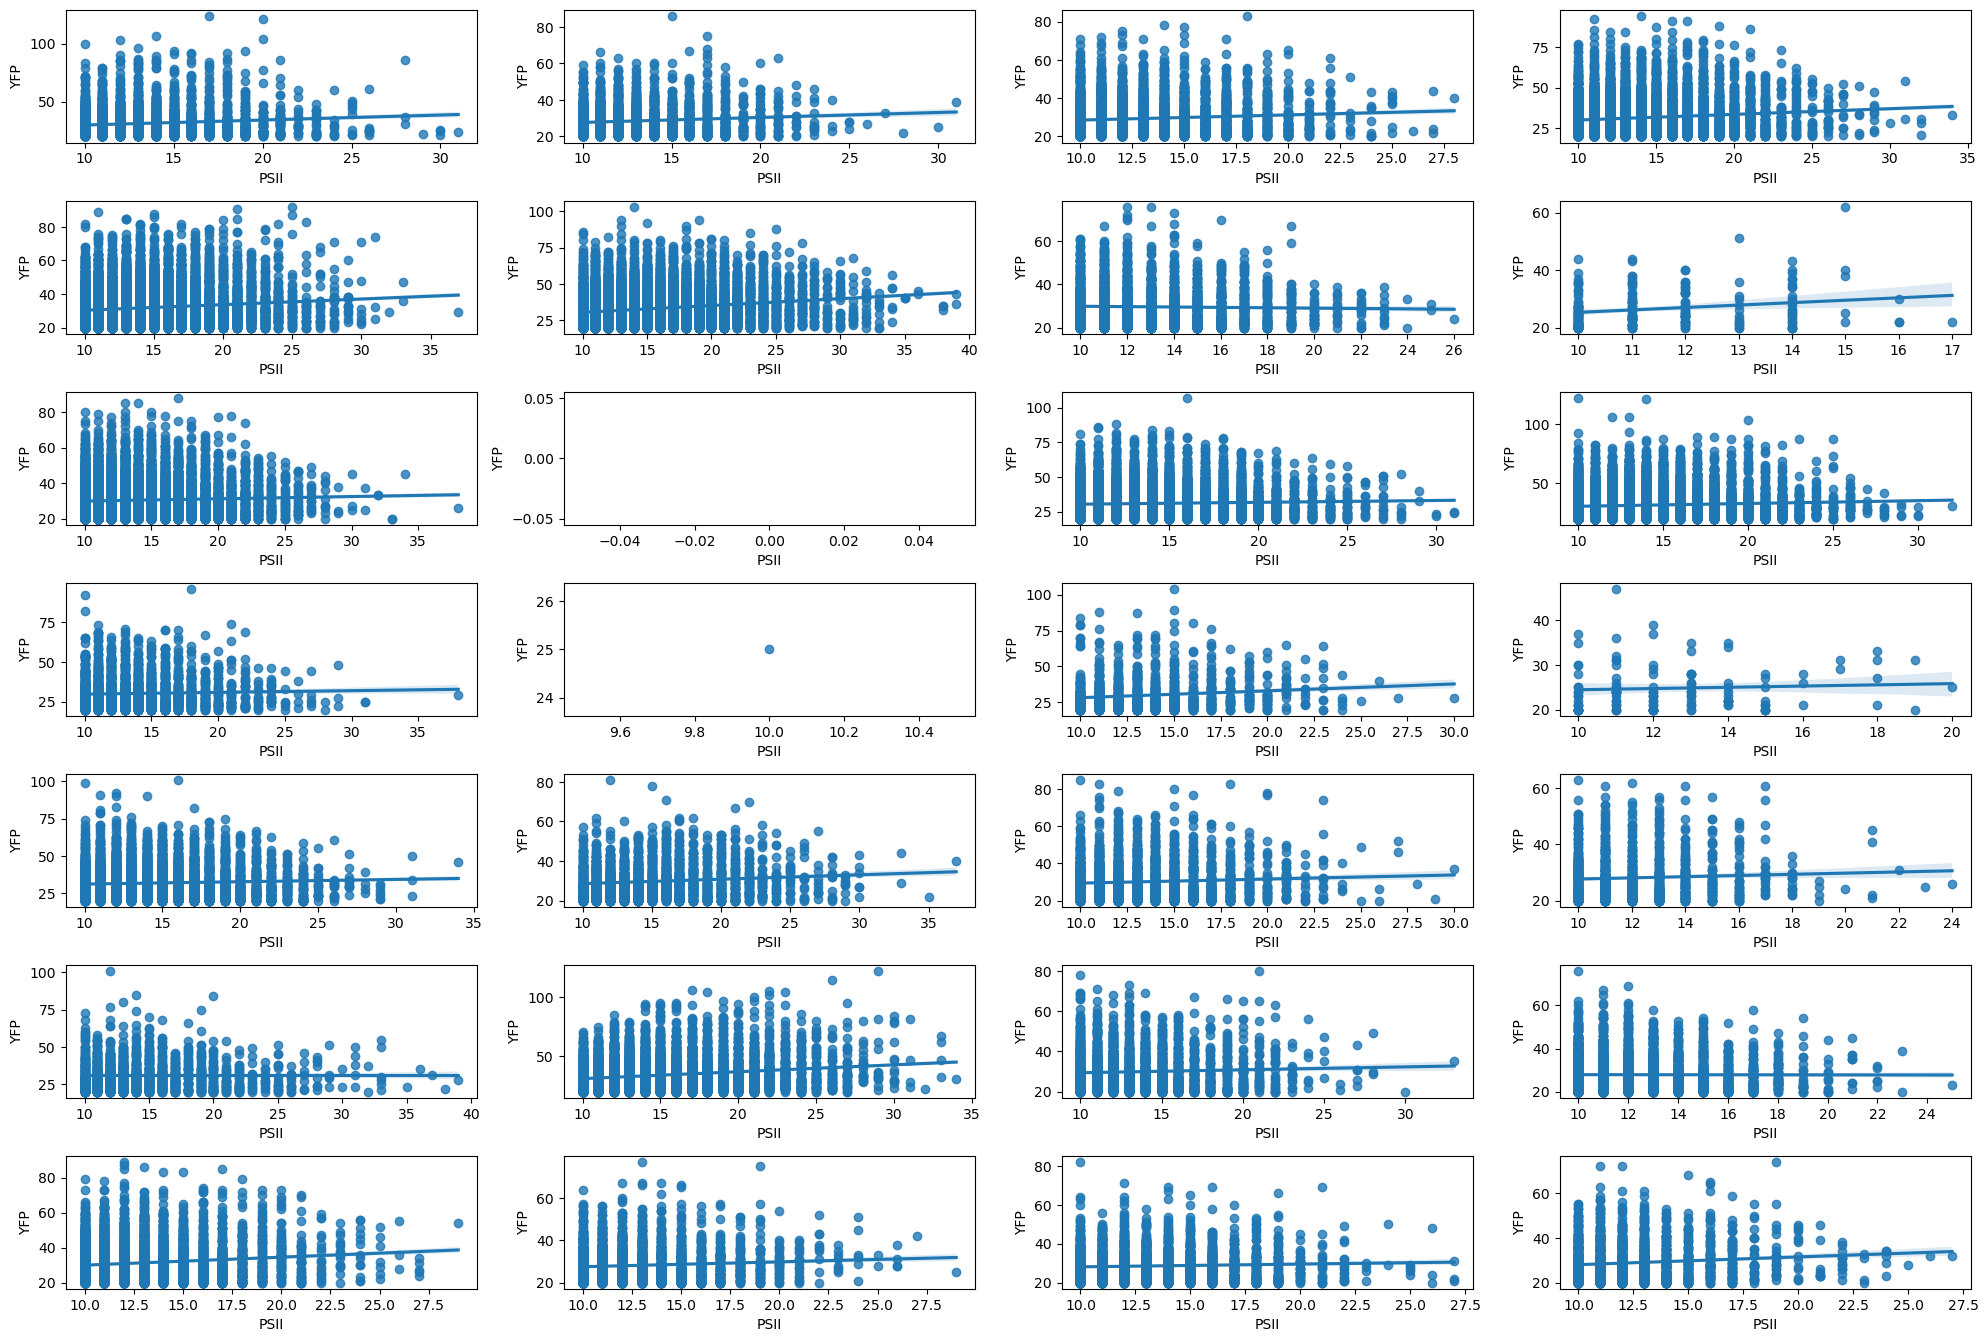

In [189]:
plt.figure(figsize=(20, 15))

size = len(files_raw)
r,c = 8,4

for i in range(size):
        plt.subplot((r),(c),(i+1))
        sns.regplot(x=df_list[i]['PSII'], y=df_list[i]['YFP'])


plt.tight_layout()
plt.show()